# Priority Rules in Retrosynthetic Planning

This notebook demonstrates how to steer SynPlanner with a small, curated set of reaction rules. We embed Ugi retrosynthetic SMARTS directly in the notebook, convert them to `Reactor` objects, run MCTS with priority rules enabled, and inspect whether solved routes use those curated disconnections.

In this workflow, you will:

- import the SynPlanner planning utilities
- download and load the article preset resources
- define priority rules from embedded SMARTS text
- run MCTS with `use_priority=True`
- save route and search statistics
- analyze where priority rules appear in solved routes

**Prerequisites:** access to the SynPlanner article preset data. No separate priority-rule file is required.

## 1. Import Dependencies

Import the plotting, notebook display, chemistry, tree-search, and loading utilities used throughout the tutorial.

In [1]:
import csv
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import SVG, display

from chython.reactor.reactor import Reactor
from synplan.chem.utils import mol_from_smiles
from synplan.mcts.tree import Tree
from synplan.utils.config import RDKitEvaluationConfig, TreeConfig
from synplan.utils.loading import (
    download_preset,
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)
from synplan.utils.visualisation import get_route_svg

## 2. Load Preset Data

Download the article preset and collect the model, rule, and building-block paths used later. The helper reuses cached files when they are already available.

In [2]:
# Download SynPlanner preset data
paths = download_preset("synplanner-article", save_to="synplan_data")

# Paths to resources
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]

## 3. Load Search Components

Load the default building blocks, policy-ranked reaction-rule library, and ranking policy. These provide broad coverage; priority rules are added separately in the next section.

In [3]:
building_blocks = load_building_blocks(
    building_blocks_path,
    standardize=False,
    silent=False,
)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_function = load_policy_function(weights_path=ranking_policy_network)

print(f"Building blocks: {len(building_blocks):,}")
print(f"Default reaction rules: {len(reaction_rules):,}")

Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint synplan_data/policy/supervised_gcn/v1/v1/ranking_policy.ckpt`


Building blocks: 186,868
Default reaction rules: 24,094


## 4. Define Priority Rules

The Ugi priority rules are kept in a plain text block with the original `rule_smarts` header. Each non-header line is parsed into a `Reactor`, so the notebook is self-contained and does not depend on any separate rule file.

In [4]:
priority_rules_text = """
[C;D3:1](-[N;D2:2]-[C;D3:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D1:8])-[C;D3:9](=[O;D1:10])-[C;D2:11])=[O;D1:12]>>[C;D2:4](-[C;D3:5])=[O;D1:6].[N;D1:7]-[C;D1:8].[C;D3:9](=[O;D1:10])(-[C;D2:11])-[O;D1:12].[C;D1-:1]#[N;D2+:2]-[C;D3:3]
[C;D3:1](-[N;D2:2]-[C;D2:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D2:8])-[C;D3:9](=[O;D1:10])-[C;D4:11])=[O;D1:12]>>[C;D1-:1]#[N;D2+:2]-[C;D2:3].[C;D3:9](=[O;D1:10])(-[C;D4:11])-[O;D1:12].[N;D1:7]-[C;D2:8].[C;D2:4](-[C;D3:5])=[O;D1:6]
[C;D3:1](-[N;D2:2]-[C;D2:3])(-[C;D3:4](-[C;D2:5])-[N;D3:7](-[C;D3:8])-[C;D3:9](=[O;D1:10])-[C;D3:11])=[O;D1:12]>>[N;D1:7]-[C;D3:8].[C;D2:4](-[C;D2:5])=[O;D1:6].[C;D1-:1]#[N;D2+:2]-[C;D2:3].[C;D3:9](=[O;D1:10])(-[C;D3:11])-[O;D1:12]
[C;D3:1](-[N;D2:2]-[C;D4:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D2:8])-[C;D3:9](=[O;D1:10])-[C;D3:11])=[O;D1:12]>>[C;D3:9](=[O;D1:10])(-[C;D3:11])-[O;D1:12].[N;D1:7]-[C;D2:8].[C;D2:4](-[C;D3:5])=[O;D1:6].[C;D1-:1]#[N;D2+:2]-[C;D4:3]
[C;D3:1](-[N;D2:2]-[C;D3:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D3:8])-[C;D3:9](=[O;D1:10])-[C;D3:11])=[O;D1:12]>>[C;D1-:1]#[N;D2+:2]-[C;D3:3].[N;D1:7]-[C;D3:8].[C;D3:9](=[O;D1:10])(-[C;D3:11])-[O;D1:12].[C;D2:4](-[C;D3:5])=[O;D1:6]
[C;D2:2](-[N;D3:3](-[C;D3:4](=[O;D1:9])-[C;D3:10])-[C;D2:11])-[C;D3:6](=[O;D1:5])-[N;D2:7]-[C;D2:8]>>[O;D1:1]=[C;D1:2].[C;D1-:6]#[N;D2+:7]-[C;D2:8].[N;D1:3]-[C;D2:11].[C;D3:4](-[O;D1:5])(=[O;D1:9])-[C;D3:10]
[C;D3:1](-[N;D2:2]-[C;D2:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D2:8])-[C;D3:9](=[O;D1:10])-[C;D2:11])=[O;D1:12]>>[C;D1-:1]#[N;D2+:2]-[C;D2:3].[C;D3:9](=[O;D1:10])(-[C;D2:11])-[O;D1:12].[N;D1:7]-[C;D2:8].[C;D2:4](-[C;D3:5])=[O;D1:6]
[C;D3:1](-[N;D2:2]-[C;D4:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D2:8])-[C;D3:9](=[O;D1:10])-[C;D2:11])=[O;D1:12]>>[C;D1-:1]#[N;D2+:2]-[C;D4:3].[C;D3:9](=[O;D1:10])(-[C;D2:11])-[O;D1:12].[C;D2:4](-[C;D3:5])=[O;D1:6].[N;D1:7]-[C;D2:8]
[C;D3:1](-[N;D2:2]-[C;D4:3])(-[C;D3:4](-[C;D3:5])-[N;D3:7](-[C;D1:8])-[C;D3:9](=[O;D1:10])-[C;D2:11])=[O;D1:12]>>[C;D1-:1]#[N;D2+:2]-[C;D4:3].[C;D3:9](=[O;D1:10])(-[C;D2:11])-[O;D1:12].[C;D2:4](-[C;D3:5])=[O;D1:6].[N;D1:7]-[C;D1:8]
[C;D2:1]-[C;D4:2](-[C;D2:3])(-[C;D3:4](=[O;D1:5])-[N;D2:11]-[C;D4:12])-[N;D3:9](-[C;D3:6](-[C;D2:7])=[O;D1:8])-[C;D2:10]>>[C;D1-:4]#[N;D2+:11]-[C;D4:12].[O;D1:5]-[C;D3:6](-[C;D2:7])=[O;D1:8].[N;D1:9]-[C;D2:10].[C;D2:1]-[C;D3:2](-[C;D2:3])=[O;D1:13]
"""

ugi_rule_smarts = [
    line.strip()
    for line in priority_rules_text.splitlines()
    if line.strip()
]

ugi_rules = [
    Reactor.from_smarts(
        rule_smarts,
        automorphism_filter=False,
        delete_atoms=False,
    )
    for rule_smarts in ugi_rule_smarts
]

# priority_rules is a mapping {set_name: [Reactor, ...]}. Each set's name
# becomes the rule_source label on every child the set produces, and shows
# up in tree.stats.per_priority_source[<name>] as its own counter pair.
# To add another curated set, just add another key, e.g.:
#     priority_rules = {"ugi": ugi_rules, "boc_deprotection": boc_rules}
# Reserved key: "policy" (raises ValueError — it tags the policy bucket).
priority_rules = {"ugi": ugi_rules}

print(f"Priority rule sets: {list(priority_rules)}")
for name, rules in priority_rules.items():
    print(f"  {name}: {len(rules)} rules")

Priority rule sets: ['ugi']
  ugi: 10 rules


## 5. Define the Target

Use a target where Ugi-style disconnections are chemically relevant. This makes it easier to see whether the priority rules influence the route search.

In [5]:
example_smiles = 'CC(C)(C)[Si](C)(C)OCC(CO[Si](C)(C)C(C)(C)C)(N(C(=O)C=CC)Cc1ccc(cc1)OC)C(=O)NC(C)(C)C'

target_molecule = mol_from_smiles(
    example_smiles,
    clean2d=True,
    standardize=True,
    clean_stereo=True,
)

target_molecule

## 6. Configure and Run Search

Enable priority rules with `use_priority=True`. Matching priority rules are attempted before policy-ranked rules for each precursor, while the learned policy remains available as fallback.

In [6]:
tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=500,
    max_time=120,
    max_depth=6,
    min_mol_size=0,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
    use_priority=True,
    priority_rule_multiapplication=False,
)

eval_config = RDKitEvaluationConfig(score_function="weight")
evaluation_function = load_evaluation_function(eval_config)

tree_config

TreeConfig(max_iterations=500, max_tree_size=1000000, max_time=120.0, max_depth=6, exclude_small=True, min_mol_size=0, silent=False, algorithm='uct', normalize_scores=False, max_rules_applied=10, stop_at_first=False, enable_pruning=False, use_priority=True, priority_rule_multiapplication=False, search_strategy='expansion_first', ucb_type='uct', c_ucb=0.1, backprop_type='muzero', evaluation_agg='max', epsilon=0.0, init_node_value=0.5, beam_width=10, nmcs_level=2, nmcs_playout_mode='greedy', lnmcs_ratio=0.2)

In [7]:
tree = Tree(
    target=target_molecule,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_function,
    evaluation_function=evaluation_function,
    priority_rules=priority_rules,
)

In [8]:
for solved, node_id in tree:
    pass

tree

  0%|          | 0/500 [00:00<?, ?it/s]

Tree for: CC(C)(C)[Si](C)(C)OCC(CO[Si](C)(C)C(C)(C)C)(N(C(=O)C=CC)Cc1ccc(cc1)OC)C(=O)NC(C)(C)C
Time: 7.2 seconds
Number of nodes: 3499
Number of iterations: 500
Number of visited nodes: 488
Number of found routes: 484

## 7. Export Search Statistics

The CSV gives a compact run summary. The JSON keeps richer route details, including rule-source labels and branching statistics for later analysis.

In [9]:
RESULTS_DIR = Path('tutorial_results/')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

stats = tree.to_stats_dict()
stats["target_smiles"] = example_smiles

csv_path = RESULTS_DIR / "priority_rules_tree_stats.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=stats.keys())
    writer.writeheader()
    writer.writerow(stats)

analysis = {
    "target_smiles": example_smiles,
    "summary": stats,
    "branching_profile": tree.branching_profile(),
    "route_details": [tree.route_details(node_id) for node_id in tree.winning_nodes],
    "winning_rule_ranks": tree.winning_rule_ranks(),
    "routes_found_at": tree.stats.routes_found_at,
}

json_path = RESULTS_DIR / "priority_rules_tree_analysis.json"
with open(json_path, "w") as f:
    json.dump(analysis, f, indent=2, default=str)

print(f"Stats saved to {csv_path}")
print(f"Analysis saved to {json_path}")
for key, value in stats.items():
    print(f"  {key}: {value}")

Stats saved to tutorial_results/priority_rules_tree_stats.csv
Analysis saved to tutorial_results/priority_rules_tree_analysis.json
  num_routes: 484
  num_nodes: 3499
  num_iter: 500
  tree_depth: 6
  search_time: 7.2
  solved: True
  expansion_calls: 300
  expansion_successes: 300
  total_rules_tried: 15015
  total_rules_succeeded: 3335
  policy_rules_tried: 15000
  policy_rules_succeeded: 3320
  rule_applicability_rate: 0.2221
  dead_end_nodes: 0
  priority_rules_tried: 15
  priority_rules_succeeded: 15
  per_priority_source: {'ugi': {'tried': 15, 'succeeded': 15}}
  n_routes_with_priority: 481
  fraction_routes_with_priority: 0.993801652892562
  first_solution_iteration: 4
  first_solution_time: 0.0771
  max_branching_factor: 34
  mean_branching_factor: 11.66
  best_route_score: 0.156928
  mean_winning_rule_rank: 6.8
  target_smiles: CC(C)(C)[Si](C)(C)OCC(CO[Si](C)(C)C(C)(C)C)(N(C(=O)C=CC)Cc1ccc(cc1)OC)C(=O)NC(C)(C)C


## 8. Visualize Routes

Display the highest-scoring solved routes first. If no route is solved, increase the time limit, iteration limit, or search depth and rerun the search.

In [10]:
MAX_ROUTES_TO_DISPLAY = 5

winning_nodes = sorted(tree.winning_nodes, key=tree.route_score, reverse=True)

if not winning_nodes:
    print("No solved routes were found. Increase max_time, max_iterations, or max_depth and rerun the search.")
else:
    for rank, node_id in enumerate(winning_nodes[:MAX_ROUTES_TO_DISPLAY], start=1):
        print(
            f"Route {rank}: node #{node_id}, "
            f"score={tree.route_score(node_id):.4f}, "
            f"length={tree.route_details(node_id)['route_length']}"
        )
        display(SVG(get_route_svg(tree, node_id, labeled=True)))

Route 1: node #101, score=0.1569, length=3


Route 2: node #91, score=0.1569, length=3


Route 3: node #145, score=0.1568, length=3


Route 4: node #155, score=0.1568, length=3


Route 5: node #199, score=0.1567, length=3


## 9. Analyze Priority-Rule Usage

Route steps record `rule_source`, `rule_key`, and `policy_rank`. A policy step has `rule_source == "policy"`; every other value is the name of a priority set passed to `Tree(priority_rules={...})` — `"ugi"` here. The analysis below treats *any non-policy* source as priority, which is the right shape when you have multiple curated sets in the same search.

In [11]:
def priority_usage_from_tree(tree: Tree):
    route_rows = []
    priority_by_step = Counter()
    priority_by_rule = Counter()

    route_ids = sorted(tree.winning_nodes, key=tree.route_score, reverse=True)
    for route_id in route_ids:
        details = tree.route_details(route_id)
        priority_steps = []
        priority_rule_keys = []

        for step in details["steps"]:
            if step["rule_source"] != "policy" and step["rule_source"] is not None:
                step_no = step["depth"]
                rule_key = step["rule_key"]
                priority_steps.append(step_no)
                priority_rule_keys.append(rule_key)
                priority_by_step[step_no] += 1
                priority_by_rule[rule_key] += 1

        route_rows.append(
            {
                "winning_node_id": route_id,
                "route_score": details["route_score"],
                "route_length": details["route_length"],
                "used_priority": bool(priority_steps),
                "n_priority_steps": len(priority_steps),
                "priority_steps": priority_steps,
                "priority_rule_keys": priority_rule_keys,
            }
        )

    routes = pd.DataFrame(route_rows)
    max_step = int(routes["route_length"].max()) if not routes.empty else 0
    step_counts = pd.DataFrame(
        {
            "step": list(range(1, max_step + 1)),
            "priority_rule_uses": [priority_by_step.get(step, 0) for step in range(1, max_step + 1)],
        }
    )
    rule_counts = pd.DataFrame(
        priority_by_rule.most_common(),
        columns=["rule_key", "uses"],
    )

    n_routes_with_priority = int(routes["used_priority"].sum()) if not routes.empty else 0
    summary = {
        "n_winning_routes": len(route_ids),
        "n_routes_with_priority": n_routes_with_priority,
        "fraction_routes_with_priority": (
            n_routes_with_priority / len(route_ids) if route_ids else 0.0
        ),
        "priority_rules_tried": tree.stats.priority_rules_tried,
        "priority_rules_succeeded": tree.stats.priority_rules_succeeded,
    }

    return summary, routes, step_counts, rule_counts


priority_summary, route_priority_table, priority_step_counts, priority_rule_counts = priority_usage_from_tree(tree)

display(pd.Series(priority_summary, name="value").to_frame())

# Per-source breakdown — one row per priority set defined in
# Tree(priority_rules={...}). Useful when running with multiple curated sets.
per_source = pd.DataFrame(
    [
        {"set": name, "tried": c.tried, "succeeded": c.succeeded}
        for name, c in tree.stats.per_priority_source.items()
    ]
)
if not per_source.empty:
    display(per_source.set_index("set"))

display(route_priority_table.head(10))

,value
n_winning_routes,484.000000
n_routes_with_priority,481.000000
fraction_routes_with_priority,0.993802
priority_rules_tried,15.000000
priority_rules_succeeded,15.000000


,tried,succeeded
set,,
ugi,15,15


,winning_node_id,route_score,route_length,used_priority,n_priority_steps,priority_steps,priority_rule_keys
0,101,0.156928,3,True,1,[1],[ugi:9]
1,91,0.156928,3,True,1,[1],[ugi:9]
2,145,0.156755,3,True,1,[1],[ugi:9]
3,155,0.156755,3,True,1,[1],[ugi:9]
4,199,0.156727,3,True,1,[2],[ugi:9]
5,188,0.156727,3,True,1,[2],[ugi:9]
6,259,0.150247,3,True,1,[2],[ugi:9]
7,248,0.150247,3,True,1,[2],[ugi:9]
8,1415,0.149850,3,True,1,[3],[ugi:9]
9,1947,0.144032,3,True,1,[3],[ugi:9]


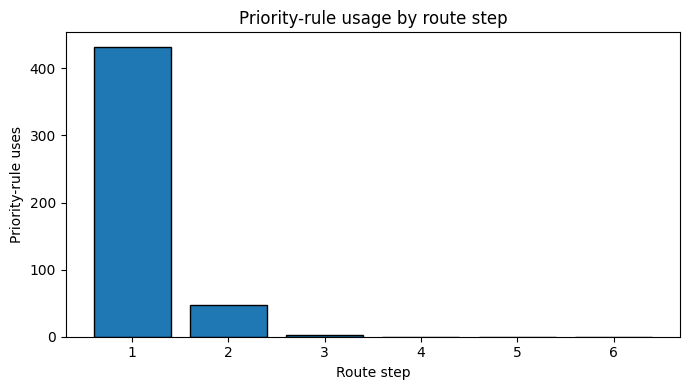

,rule_key,uses
0,ugi:9,481


In [12]:
if priority_step_counts.empty or priority_step_counts["priority_rule_uses"].sum() == 0:
    print("No priority-rule usage in solved routes.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(priority_step_counts["step"], priority_step_counts["priority_rule_uses"], edgecolor="black")
    ax.set_xlabel("Route step")
    ax.set_ylabel("Priority-rule uses")
    ax.set_title("Priority-rule usage by route step")
    ax.set_xticks(priority_step_counts["step"])
    plt.tight_layout()
    plt.show()

priority_rule_counts.head(10)

In [13]:
priority_step_counts["priority_rule_uses"]

0    432
1     47
2      2
3      0
4      0
5      0
Name: priority_rule_uses, dtype: int64

## 10. Baseline Comparison

Run the same target with priority rules disabled and compare the search statistics. Set `RUN_BASELINE_COMPARISON = False` to skip this extra search when you only need the priority-rule run.

In [14]:
RUN_BASELINE_COMPARISON = True

if RUN_BASELINE_COMPARISON:
    baseline_config = tree_config.model_copy(update={"use_priority": False})
    baseline_tree = Tree(
        target=target_molecule,
        config=baseline_config,
        reaction_rules=reaction_rules,
        building_blocks=building_blocks,
        expansion_function=policy_function,
        evaluation_function=evaluation_function,
        priority_rules=priority_rules,
    )
    for _solved, _node_id in baseline_tree:
        pass

    comparison = pd.DataFrame(
        [
            {"run": "with_priority", **tree.to_stats_dict()},
            {"run": "baseline", **baseline_tree.to_stats_dict()},
        ]
    ).set_index("run")

    display(
        comparison[
            [
                "num_routes",
                "num_nodes",
                "num_iter",
                "search_time",
                "best_route_score",
                "n_routes_with_priority",
                "fraction_routes_with_priority",
            ]
        ]
    )
else:
    print("Set RUN_BASELINE_COMPARISON = True and rerun this cell to compare against a no-priority search.")

  0%|          | 0/500 [00:00<?, ?it/s]

,num_routes,num_nodes,num_iter,search_time,best_route_score,n_routes_with_priority,fraction_routes_with_priority
run,,,,,,,
with_priority,484,3499,500,7.2,0.156928,481,0.993802
baseline,4,4032,500,11.0,0.086301,0,0.000000


## Summary

Priority rules are useful when you have trusted disconnections that should be tried ahead of the learned policy. Use these diagnostics to check whether they are genuinely affecting the search:

- `priority_rules_tried` and `priority_rules_succeeded`: how often curated rules matched and produced valid precursor sets
- `n_routes_with_priority`: how many solved routes contain at least one priority-rule step
- priority-rule usage by route step: whether curated chemistry is influencing early or late disconnections
- route SVGs and `route_details`: the chemical context for each priority-rule application